In [1]:
import os
os.chdir(r"C:\Users\Annie.LAPTOP-NJ5KV9M1\AGN_mapping")

In [2]:
pip install astropy scipy matplotlib numpy h5py tqdm numba pint-pulsar emcee corner statsmodels pyfftw tbb

In [3]:
pip install pytest pytest-astropy jinja2 docutils sphinx-astropy nbsphinx pandoc ipython jupyter notebook towncrier tox black

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install stingray PyROA emcee tabulate corner astropy

In [5]:
import shutil

# Replace '/path/to/work_directory' with your actual work directory

src = r'C:\Users\Annie.LAPTOP-NJ5KV9M1\AGN_mapping\CPython\PYCCF.py'
dst = r'PYCCF.py'
dst2 = r'xcorspc.pyx'

shutil.copy(src, dst)
shutil.copy(src, dst2)

'xcorspc.pyx'

In [6]:
import os
print(os.getcwd())

C:\Users\Annie.LAPTOP-NJ5KV9M1\AGN_mapping


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import argparse
import random

from scipy import stats
import scipy.integrate as integrate

from stingray import Lightcurve, Crossspectrum, AveragedCrossspectrum

import PYCCF as myccf
import PyROA
import psi

import importlib
importlib.reload(psi)


<module 'psi' from 'C:\\Users\\Annie.LAPTOP-NJ5KV9M1\\AGN_mapping\\psi.py'>

In [8]:
import scipy
print(scipy.__version__)
print(scipy.__file__)

1.15.2
c:\Users\Annie.LAPTOP-NJ5KV9M1\miniconda3\envs\agn\lib\site-packages\scipy\__init__.py


In [9]:
#import AGN light curve
directory_path = r'C:\Users\Annie.LAPTOP-NJ5KV9M1\AGN_mapping\data'
file_path = os.path.join(directory_path, 'lc30mins.dat')

column_index1 = 0  
column_index2 = 1

with open(file_path, 'r') as file:
    # Read all lines
    lines = file.readlines()
    data_lines = lines[1:]
    
   # Extract the desired columns from each line and convert to float
    column1_data = [float(line.split()[column_index1]) for line in data_lines]
    column2_data = [float(line.split()[column_index2]) for line in data_lines]

time = np.array(column1_data)/(24*3600)
flux = np.array(column2_data)

dt = 1800 #each interval in seconds 

exposure = len(time) #length of full array 
seconds_day = 86400
original_length = exposure/(seconds_day/dt)

#times = (np.linspace(-exposure, exposure+1, num = exposure*2)*dt)/(24*3600) # converted to days
times = (np.linspace(1, exposure+1, num = exposure)*dt)/(24*3600)

#define disk function
def disk(times,wavelength):
    bhmass = 10**7.7       # Msol
    mdot = 0.5         # Msol/yr
    inc = 45           # inclination, degrees
    combi_psi = psi.pytfb_sub(times,1e8,mdot,wavelength,inc,norm=1)
    combi_psi[np.isnan(combi_psi)]=0
    # normalise 
    normi = np.trapz(combi_psi,x=times)
    return (combi_psi/normi)


combi_psi_1 = disk(times, 4770)


## below checking the disk response function to see if it is normalised


In [10]:
# integrate disk response function

normalisation = np.trapz(combi_psi_1, times)
mean_lag = np.trapz(times * combi_psi_1, x=times)

print("Integral =", normalisation)
print("Mean lag =", mean_lag)

Integral = 0.9999999999999999
Mean lag = 2.046051304530122


In [11]:
psi_norm = combi_psi_1 / np.sum(combi_psi_1)

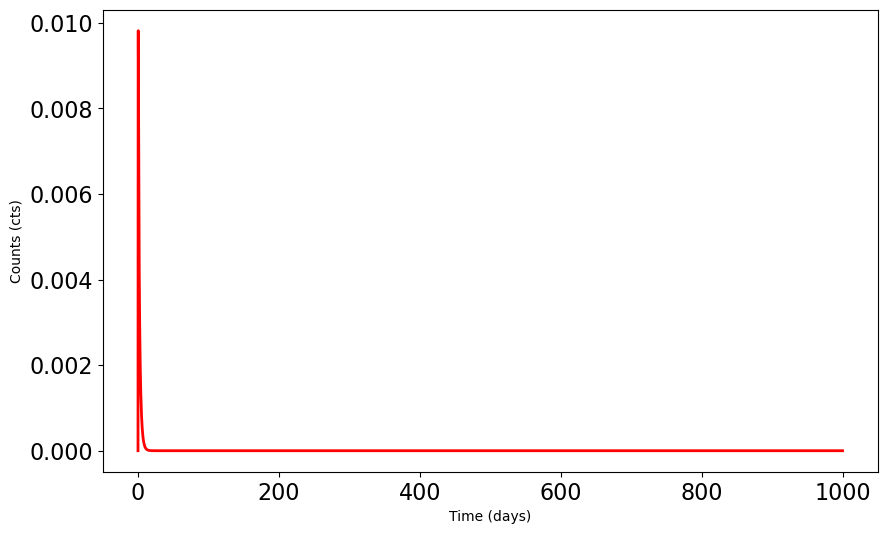

In [12]:
#plot of PSD based light curve
fig, ax = plt.subplots(1,1,figsize=(10,6))
ax.plot(times, psi_norm, lw=2, color='red')
#ax.set_xlim(-10,100)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Counts (cts)")
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
plt.show()

In [13]:
print(len(times))
print(len(time))



48000
48000


In [15]:
signal_DISK = np.convolve(flux, psi_norm, mode='full')

#start_index2 = int((len(signal_DISK) - len(flux)) / 2)
#end_index2 = start_index2 + len(flux)
#signal_DISK = signal_DISK[start_index2:end_index2]

zero_idx = np.argmin(np.abs(times))
signal_DISK = signal_DISK[zero_idx:zero_idx + len(flux)]

# ---- CROP EDGE EFFECTS ----
# Estimate width of transfer function (in days)
tf_width = np.max(times[psi_norm > 0.01 * np.max(psi_norm)])

# Create mask to remove initial edge-affected region
mask = time > tf_width

# Apply mask to BOTH light curves
time_cut = time[mask]
flux_cut = flux[mask]
signal_cut = signal_DISK[mask]

#signal_DISK = signal_DISK[:len(time)]
lc_DISK = Lightcurve(time_cut, signal_cut)
lc = Lightcurve(time_cut, flux_cut)

c:\Users\Annie.LAPTOP-NJ5KV9M1\miniconda3\envs\agn\lib\site-packages\stingray\lightcurve.py:329: UserWarning: On Windows, the size of an integer is 32 bits. To avoid integer overflow, I'm converting the input array to float
  warnings.warn(


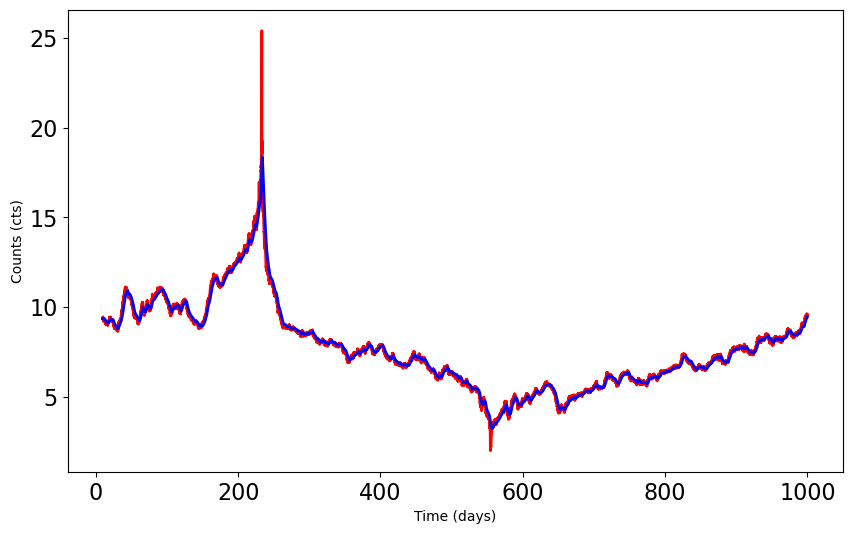

In [16]:
#plot of PSD based light curve
fig, ax = plt.subplots(1,1,figsize=(10,6))
ax.plot(lc.time, lc.counts, lw=2, color='red')
ax.plot(lc_DISK.time, lc_DISK.counts, lw=2, color='blue')
ax.set_xlabel("Time (days)")
ax.set_ylabel("Counts (cts)")
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
plt.show()

In [17]:
expected_index = len(combi_psi_1) // 2
print("Expected index of the peak:", expected_index)    

Expected index of the peak: 24000


In [18]:
np.argmax(combi_psi_1)


16

In [19]:
print(lc.time)
print(lc_DISK.time)

[  9.72916667   9.75         9.77083333 ... 999.9375     999.95833333
 999.97916667]
[  9.72916667   9.75         9.77083333 ... 999.9375     999.95833333
 999.97916667]


finding the centroid of the cross correlation function manually 

In [20]:
from stingray.crosscorrelation import CrossCorrelation

cc = CrossCorrelation(lc, lc_DISK)

lags = cc.time_lags
ccf  = cc.corr

mask = ccf > 0.8 * np.max(ccf)

tau_cent = np.sum(
    lags[mask] * ccf[mask]
) / np.sum(ccf[mask])

print("Centroid of the CCF:", tau_cent)

Centroid of the CCF: -1.826144267177494


In [21]:
mean_lag = np.sum(times * combi_psi_1) / np.sum(combi_psi_1)
print("Mean lag from the disk response function:", mean_lag)

Mean lag from the disk response function: 2.0460513045301223


In [22]:
import shutil

# Replace '/path/to/work_directory' with your actual work directory

src = r'C:\Users\Annie.LAPTOP-NJ5KV9M1\AGN_mapping\CPython\PYCCF.py'
dst = r'PYCCF.py'
dst2 = r'xcorspc.pyx'

shutil.copy(src, dst)
shutil.copy(src, dst2)


'xcorspc.pyx'

In [24]:
import sys
import argparse
import PYCCF as myccf

#########################################
##Set Interpolation settings, user-specified
#########################################
lag_range = [-10, 10]  #Time lag range to consider in the CCF (days). Must be small enough that there is some overlap between light curves at that shift (i.e., if the light curves span 80 days, these values must be less than 80 days)
interp = 0.02 #Interpolation time step (days). Must be less than the average cadence of the observations, but too small will introduce noise.
nsim = 50  #Number of Monte Carlo iterations for calculation of uncertainties
mcmode = 0  #Do both FR/RSS sampling (1 = RSS only, 2 = FR only) 
sigmode = 0.2  #Choose the threshold for considering a measurement "significant". sigmode = 0.2 will consider all CCFs with r_max <= 0.2 as "failed". See code for different sigmodes.


In [ ]:

##########################################
#Calculate lag with python CCF program
##########################################

mjd2 = lc_DISK.time
flux2 = lc_DISK.counts
mjd1 = lc.time
flux1 = lc.counts 
err1 = abs(flux1*0.01)
err2 = abs(flux2*0.01)

#dwnsizing s it will run faster for testing purposes
factor = 10  # or even 20
mjd1_ds = mjd1[::factor]
flux1_ds = flux1[::factor]
err1_ds = err1[::factor]

mjd2_ds = mjd2[::factor]
flux2_ds = flux2[::factor]
err2_ds = err2[::factor]

print("Testing CCF...")
tlag_peak, _, tlag_centroid, _, ccf_pack, _, _, _ = myccf.peakcent(
    mjd1_ds, flux1_ds, mjd2_ds, flux2_ds,
    lag_range[0], lag_range[1],
    interp
)
print(tlag_peak, tlag_centroid)

In [ ]:

print("Starting MC...")
#tlag_peak, status_peak, tlag_centroid, status_centroid, ccf_pack, max_rval, status_rval, pval = myccf.peakcent(mjd1_ds, flux1_ds, mjd2_ds, flux2_ds, lag_range[0], lag_range[1], interp)
tlags_peak, tlags_centroid, nsuccess_peak, nfail_peak, nsuccess_centroid, nfail_centroid, max_rvals, nfail_rvals, pvals = myccf.xcor_mc(mjd1_ds, flux1_ds, abs(err1_ds), mjd2_ds, flux2_ds, abs(err2_ds), lag_range[0], lag_range[1], interp, nsim = nsim, mcmode=mcmode, sigmode = 0.2)
print("Finished MC")
lag = ccf_pack[1]
r = ccf_pack[0]

perclim = 84.1344746  

print(tlag_centroid,tlag_peak)
print("Done")

In [ ]:
from scipy import stats 

###Calculate the best peak and centroid and their uncertainties using the median of the
##distributions. 
centau = stats.scoreatpercentile(tlags_centroid, 50)
centau_uperr = (stats.scoreatpercentile(tlags_centroid, perclim))-centau
centau_loerr = centau-(stats.scoreatpercentile(tlags_centroid, (100.-perclim)))
print ('Centroid, error: %10.3f  (+%10.3f -%10.3f)'%(centau, centau_loerr, centau_uperr))

peaktau = stats.scoreatpercentile(tlags_peak, 50)
peaktau_uperr = (stats.scoreatpercentile(tlags_peak, perclim))-centau
peaktau_loerr = centau-(stats.scoreatpercentile(tlags_peak, (100.-perclim)))
print ('Peak, errors: %10.3f  (+%10.3f -%10.3f)'%(peaktau, peaktau_uperr, peaktau_loerr))

Centroid, error:        nan  (+       nan -       nan)
Peak, errors:        nan  (+       nan -       nan)


NameError: name 'lc1' is not defined

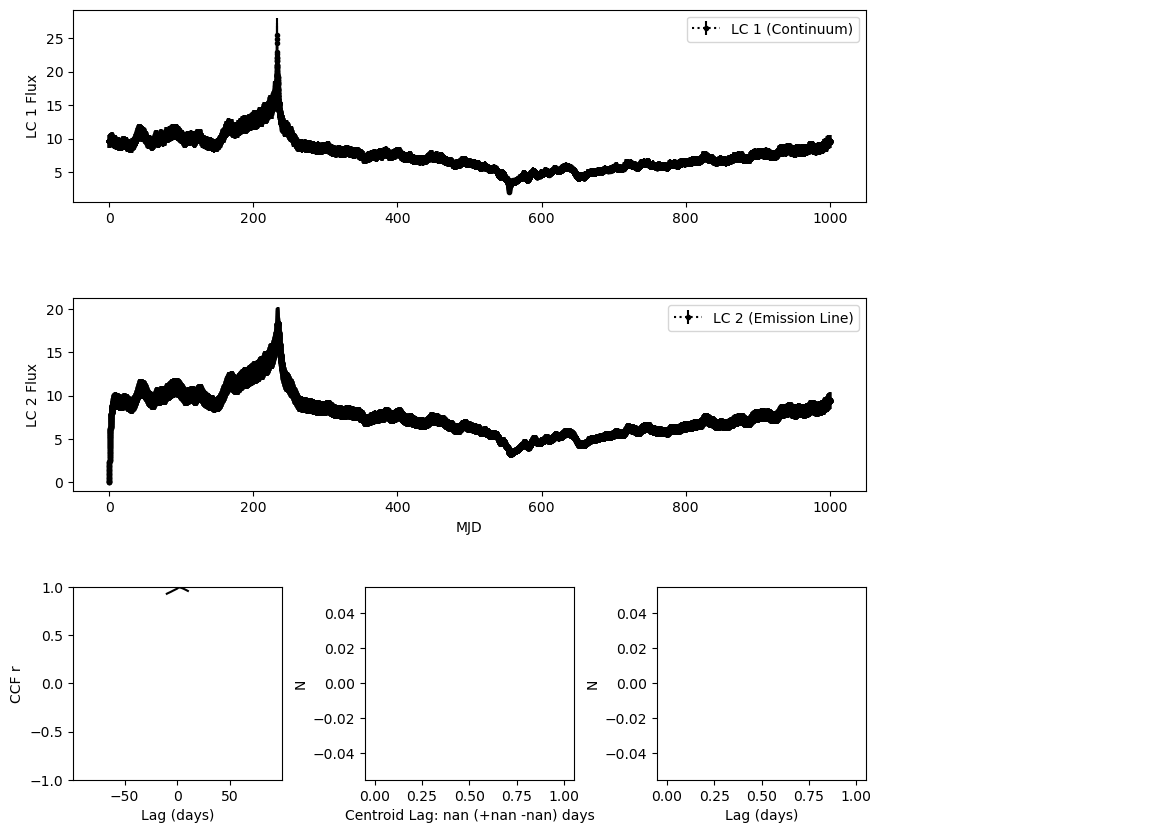

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(14, 10))
gs = GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4)

# -----------------------------
# Light Curves (full width)
# -----------------------------
ax1 = fig.add_subplot(gs[0, 0:3])
ax1.errorbar(mjd1, flux1, yerr=err1, marker='.', linestyle=':', color='k', label='LC 1 (Continuum)')
ax1.set_ylabel('LC 1 Flux')
ax1.legend(loc='upper right')

ax2 = fig.add_subplot(gs[1, 0:3], sharex=ax1)
ax2.errorbar(mjd2, flux2, yerr=err2, marker='.', linestyle=':', color='k', label='LC 2 (Emission Line)')
ax2.set_ylabel('LC 2 Flux')
ax2.set_xlabel('MJD')
ax2.legend(loc='upper right')

# -----------------------------
# CCF plots
# -----------------------------
ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(lag, r, color='k')
ax3.set_xlim(-99, 99)
ax3.set_ylim(-1.0, 1.0)
ax3.set_ylabel('CCF r')
ax3.set_xlabel('Lag (days)')

ax4 = fig.add_subplot(gs[2, 1])
ax4.hist(tlags_centroid, bins=50, color='b')
ax4.set_xlabel(f'Centroid Lag: {centau:.1f} (+{centau_uperr:.1f} -{centau_loerr:.1f}) days')
ax4.set_ylabel('N')

ax5 = fig.add_subplot(gs[2, 2])
ax5.hist(tlags_peak, bins=50, color='b')
ax5.set_xlabel('Lag (days)')
ax5.set_ylabel('N')

# -----------------------------
# Text panel (separate, right column)
# -----------------------------
ax_text = fig.add_subplot(gs[:, 3])
ax_text.axis('off')  # no axes

# Put all text here
text_str = f"""
Light Curve 1: {lc1}
Light Curve 2: {lc2}

CCF Info:
Centroid lag: {centau:.1f} +{centau_uperr:.1f} / -{centau_loerr:.1f}
Peak lag info: ...

Other Notes:
- Monte Carlo nsim: {nsim}
- mcmode: {mcmode}
"""

ax_text.text(0, 1, text_str, verticalalignment='top', fontsize=12)

plt.show()

In [ ]:
wavelengths = [2000, 3000, 4000, 5000, 6000]

lags_out = []

for wl in wavelengths:
    psi_disk = disk(times, wl, 1)
    disk_lc = fftconvolve(flux, psi_disk, mode='same')
    
    lags, r, centroid, peak = iccf(time, flux, time, disk_lc)
    lags_out.append(centroid)

TypeError: disk() takes 2 positional arguments but 3 were given

##testing shakura-sunyaev wavelength lag dependancy 